# The GoodWords Attack

## Spam Filter Implementation

In [1]:
# initial setup and dependencies

import json
import pickle
import random
import re
import urllib.request
import zipfile
from pathlib import Path
import numpy as np

# Reproducibility
random.seed(1337)
np.random.seed(1337)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

In [3]:
from htb_ai_library import (
    AZURE,
    HACKER_GREY,
    HTB_GREEN,
    MALWARE_RED,
    NODE_BLACK,
    NUGGET_YELLOW,
    WHITE,
    AQUAMARINE,
    load_model,
    save_model,
)


In [4]:
# loading the SMS Spam Dataset

# caching mechanism to check for local copies of the dataset -- avoid unnecessary downloads

data_dir = Path("data")
data_dir.mkdir(exist_ok=True) # create data directory if it doesn't exist
dataset_path = data_dir / "sms_spam.csv"

# check for cached data
if dataset_path.exists():
    print(f"[+] Using cached dataset: {dataset_path}")
    df = pd.read_csv(dataset_path)

else:
    print("[*] Downloading from UCI Repository...")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
    zip_path = data_dir / "sms_spam.zip"

    urllib.request.urlretrieve(url, zip_path)
    # extract and process the download

    with zipfile.ZipFile(zip_path, "r") as zf:
        with zf.open("SMSSpamCollection") as f:
            lines = [line.decode("utf-8").strip() for line in f]

    data = []
    for line in lines:
        parts = line.split('\t')
        if len(parts) == 2:
            data.append({"label": parts[0].lower(), "message": parts[1]})

    df = pd.DataFrame(data)
    df.to_csv(dataset_path, index=False)
    zip_path.unlink()
    print(f"[+] Dataset saved to {dataset_path}")



[+] Using cached dataset: data/sms_spam.csv


In [5]:
# Exploring the dataset
print(f"[+] Loaded {len(df)} messages")
print(f"    Spam: {sum(df['label'] == 'spam')}")
print(f"    Ham: {sum(df['label'] == 'ham')}")

[+] Loaded 5574 messages
    Spam: 747
    Ham: 4827


In [6]:
print("\n[*] Sample messages:")
print("\nSPAM samples:")
for msg in df[df['label'] == 'spam']['message'].head(3):
    print(f"  - {msg[:80]}...")
print("\nHAM samples:")
for msg in df[df['label'] == 'ham']['message'].head(3):
    print(f"  - {msg[:80]}...")


[*] Sample messages:

SPAM samples:
  - Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8...
  - FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some...
  - WINNER!! As a valued network customer you have been selected to receivea £900 pr...

HAM samples:
  - Go until jurong point, crazy.. Available only in bugis n great world la e buffet...
  - Ok lar... Joking wif u oni......
  - U dun say so early hor... U c already then say......


In [7]:
# Preprocessing the text
# two levels of cleaning, minimal cleaning that preserves spam indicators, and final cleaning for vectorization.

# Minimal Cleaning for analysis
import html as html_module
import unicodedata

def minimal_clean(text):
    """
    Minimal cleaning that preserves spam indicators.

    Parameters: text (str) raw SMS message
    Returns: str cleaned text with entities decoded, unicode normalized, and
             whitespace collapsed while keeping informative symbols.
    """

    # Decode HTML entities to their actual characters (e.g., &amp; -> &)
    text = html_module.unescape(text)

    # Normalize unicode characters
    # converts characters to their canonical composed form - prevents identical content from being treated differently
    text = unicodedata.normalize('NFKC', text) 

    # clean up excessive whitespace
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\r+', ' ', text)

    return text.strip()

In [8]:
def clean_text(text):
    """
    Final cleaning for vectorization.

    Converts to lowercase and removes only problematic characters so that
    informative symbols remain available to the vectorizer.

    Parameters:
        text (str): Preprocessed message from `minimal_clean`.

    Returns:
        str: Normalized, whitespace‑collapsed text ready for tokenization.
    """
    # converting to lower case - ensures words like "FREE" and "free" become the same feature
    text = text.lower() 
    # Keep numbers, currency symbols, punctuation - they're spam features!
    # Only remove truly problematic characters
    text = re.sub(r'[^\w\s£$€¥!?.,;:\'\"-]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


In [9]:
# applying preprocessing
print("[*] Applying minimal text cleaning (preserving spam indicators)...")
df['preprocessed'] = df['message'].apply(minimal_clean)

# apply final cleaning for vectorization
df['clean_message'] = df['preprocessed'].apply(clean_text)

[*] Applying minimal text cleaning (preserving spam indicators)...


In [10]:
print("\n[*] Sample spam messages with preserved features:")
spam_samples = df[df['label'] == 'spam'].sample(3, random_state=42)
for idx, row in spam_samples.iterrows():
    msg = row['preprocessed'][:100] + "..." if len(row['preprocessed']) > 100 else row['preprocessed']
    print(f"  - {msg}")


[*] Sample spam messages with preserved features:
  - Summers finally here! Fancy a chat or flirt with sexy singles in yr area? To get MATCHED up just rep...
  - This is the 2nd time we have tried 2 contact u. U have won the 750 Pound prize. 2 claim is easy, cal...
  - Get ur 1st RINGTONE FREE NOW! Reply to this msg with TONE. Gr8 TOP 20 tones to your phone every week...


In [11]:
# Removing duplicates and empty messages

# remove only exact duplicates
original_size = len(df)
df = df.drop_duplicates(subset=['label', 'clean_message'])
print(f"\n[+] Removed {original_size - len(df)} duplicates")

# remove empty messages
before_empty = len(df)
df = df[df['clean_message'].str.len() > 0]
print(f"[+] Removed {before_empty - len(df)} empty messages")


# Exploring the dataset
n = len(df)
n_spam = sum(df['label'] == 'spam')
perc_spam = (n_spam/n) * 100
n_ham = sum(df['label'] == 'ham')
perc_ham = (n_ham/n) * 100
print(f"[+] Final dataset: {len(df)} messages")
print(f"    Spam: {n_spam} ({perc_spam:.1f}%)")
print(f"    Ham: {n_ham} ({perc_ham:.1f}%)")



[+] Removed 419 duplicates
[+] Removed 0 empty messages
[+] Final dataset: 5155 messages
    Spam: 638 (12.4%)
    Ham: 4517 (87.6%)


In [12]:
# Create train and test sets
# using stratified sampling to maintain the class distribution across both sets


X = df['clean_message'].values
y = df['label'].values
total = len(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_len = len(X_train)
test_len = len(X_test)
train_perc = (train_len/total) * 100
test_perc = (test_len/total) * 100
print(f"\n[+] Data split:")
print(f"    Training: {train_len} messages ({train_perc:.1f}%)")
print(f"    Testing: {test_len} messages ({test_perc:.1f}%)")


[+] Data split:
    Training: 4124 messages (80.0%)
    Testing: 1031 messages (20.0%)


In [ ]:
# training the Naive Bayes Classifier
# train a MultinomailNB classifier with a count vectorizer for feature extraction. 
# Also, implement model persistence for reproducibility

print("\n[*] Training Naive Bayes classifier...")

model_dir = Path("models")
model_dir.mkdir(exist_ok=True)
model_path = model_dir / "spam_classifier.pkl"

if model_path.exists():
    print(f"[+] Loading saved model from {model_path}")
    with open(model_path, 'rb') as f:
        saved_data = pickle.load(f)
        vectorizer = saved_data['vectorizer']
        classifier = saved_data['classifier']
    
    # transform data using existing vocabulary
    X_train_vec = vectorizer.transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

else:
    # train the model otherwise

    # Configure vectorizer to capture spam patterns
    vectorizer = CountVectorizer(
        max_features = 3000,
        token_pattern=r'\b\w+\b|[£$€¥]+|\d+|!!+|\?\?+|\.\.+',
        lowercase=True,
        stop_words='english'
    )
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    classifier = MultinomialNB()
    classifier.fit(X_train_vec, y_train)

    # Save model for reproducibility
    with open(model_path, 'wb') as f:
        pickle.dump({'vectorizer': vectorizer, 'classifier': classifier}, f)
    print(f"[+] Model saved to {model_path}")
    

In [14]:
# evaluating model performance

# calculate accuracy scores
train_acc = classifier.score(X_train_vec, y_train)
test_acc = classifier.score(X_test_vec, y_test)
print(f"[+] Training accuracy: {train_acc:.4f}")
print(f"[+] Testing accuracy: {test_acc:.4f}")

# get detailed predictions
y_pred = classifier.predict(X_test_vec)
print("\n[*] Classification Report:")
print(classification_report(y_test, y_pred))

[+] Training accuracy: 0.9920
[+] Testing accuracy: 0.9845

[*] Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.95      0.92      0.94       128

    accuracy                           0.98      1031
   macro avg       0.97      0.96      0.96      1031
weighted avg       0.98      0.98      0.98      1031



## GoodWords Attack Implementation

In [15]:
# GoodWords Extraction (White-Box)
print("\n[*] Extracting GoodWords from model...")

# get feature names and probabilities
feature_names = vectorizer.get_feature_names_out()
ham_log_probs = classifier.feature_log_prob_[0] # ham class
spam_log_probs = classifier.feature_log_prob_[1] # spam class
print(ham_log_probs[:10])



[*] Extracting GoodWords from model...
[-6.4341277  -7.77786245 -8.87647474 -7.31833012 -4.20832975 -3.51049872
 -6.52509948 -7.960184   -9.16415681 -9.16415681]


In [16]:
# calculate goodness scores

# calculate the goodness ratio to rank words by how strongly they are associated with legitimate messages

goodness_scores = []
for i, word in enumerate(feature_names):
    ham_prob = np.exp(ham_log_probs[i])
    spam_prob = np.exp(spam_log_probs[i])
    goodness = ham_prob / (spam_prob + 1e-10)
    goodness_scores.append((word, goodness, ham_prob, spam_prob))



In [17]:
# selecting the top good words

goodness_scores.sort(key=lambda x: x[1], reverse=True)
top_good_words = goodness_scores[:100]

print(f"[+] Top 10 GoodWords (most 'ham-like'):")
for word, score, hp, sp in top_good_words[:10]:
    print(f"    {word:15} | goodness: {score:8.2f} | ham_p: {hp:.4f} | spam_p: {sp:.4f}")


[+] Top 10 GoodWords (most 'ham-like'):
    lor             | goodness:    51.13 | ham_p: 0.0047 | spam_p: 0.0001
    ü               | goodness:    47.75 | ham_p: 0.0044 | spam_p: 0.0001
    ...             | goodness:    45.98 | ham_p: 0.0299 | spam_p: 0.0006
    da              | goodness:    45.87 | ham_p: 0.0043 | spam_p: 0.0001
    later           | goodness:    30.08 | ham_p: 0.0028 | spam_p: 0.0001
    doing           | goodness:    26.32 | ham_p: 0.0024 | spam_p: 0.0001
    really          | goodness:    25.57 | ham_p: 0.0024 | spam_p: 0.0001
    ask             | goodness:    24.81 | ham_p: 0.0023 | spam_p: 0.0001
    cos             | goodness:    23.69 | ham_p: 0.0022 | spam_p: 0.0001
    lol             | goodness:    23.69 | ham_p: 0.0022 | spam_p: 0.0001


In [18]:
# Attack implementation

print("\n[*] Testing GoodWords attack...")

# extract only spam message for testing
# we want to test is how well we can fool the model into classifying and originally labeled spam message as ham
spam_test_messages = X_test[y_test == 'spam']
print(f"[+] Testing on {len(spam_test_messages)} spam messages")


[*] Testing GoodWords attack...
[+] Testing on 128 spam messages


In [19]:
# Define test points from baseline (0) to saturation (40)
# 
word_counts = [i for i in range(0, 45, 5)]
attack_results = []

print(f"[*] Testing word counts: {word_counts}")

[*] Testing word counts: [0, 5, 10, 15, 20, 25, 30, 35, 40]


In [20]:
# Implementing the Attack Loop

for num_words in word_counts:
    # select the top N good words for this iteration
    selected_words = [w for w, _, _, _ in top_good_words[:num_words]]

    # show which words we're using (first iteration only for clarity)
    if num_words == 5:
        print(f"  Using words: {', '.join(selected_words)}")

  Using words: lor, ü, ..., da, later


In [21]:
# Perform message augmentation with the good words.
def augment_message(message, words_to_add):
    """Append good words to a message"""
    if len(words_to_add) > 0:
        return message + " " + " ".join(words_to_add)
    return message

# test augmentation on one example using the top 5 words
sample_spam = spam_test_messages[0]
sample_augmented = augment_message(
    sample_spam,
    [w for w, _, _, _ in top_good_words[:5]]
)
print(f"\nOriginal: {sample_spam}...")
print(f"Augmented: {sample_augmented}...")



Original: as a registered subscriber yr draw 4 a £100 gift voucher will b entered on receipt of a correct ans. when are the next olympics. txt ans to 80062...
Augmented: as a registered subscriber yr draw 4 a £100 gift voucher will b entered on receipt of a correct ans. when are the next olympics. txt ans to 80062 lor ü ... da later...


In [24]:
# Testing Evasion for Each Configuration
# testing each spam message to see if it evades detection after augmentation

attack_results = []


for num_words in word_counts:    
    # select the top N good words for this iteration
    selected_words = [w for w, _, _, _ in top_good_words[:num_words]]
    # count how many spam messages evade after augmentation
    evaded = 0
    for message in spam_test_messages:
        # augment the message
        augmented = augment_message(message, selected_words)

        # transform and predict
        vec = vectorizer.transform([augmented])
        prob = classifier.predict_proba(vec)[0]

        # check evation: ham probability > spam probability (model's decision boundary at 0.5)
        if prob[0] > prob[1]:
            evaded += 1
        
    evasion_rate = (evaded / len(spam_test_messages))*100
    attack_results.append(
        {
            'num_words': num_words,
            'evasion_rate': evasion_rate,
            'evaded': evaded,
            'total': len(spam_test_messages)
        }
    )
    print(f"  Words: {num_words:2d} | Evasion: {evasion_rate:6.2f}% ({evaded}/{len(spam_test_messages)})")



  Words:  0 | Evasion:   7.81% (10/128)
  Words:  5 | Evasion:  41.41% (53/128)
  Words: 10 | Evasion:  74.22% (95/128)
  Words: 15 | Evasion:  96.09% (123/128)
  Words: 20 | Evasion: 100.00% (128/128)
  Words: 25 | Evasion: 100.00% (128/128)
  Words: 30 | Evasion: 100.00% (128/128)
  Words: 35 | Evasion: 100.00% (128/128)
  Words: 40 | Evasion: 100.00% (128/128)


In [25]:
# Convert to DataFrame for easy plotting
results_df = pd.DataFrame(attack_results)

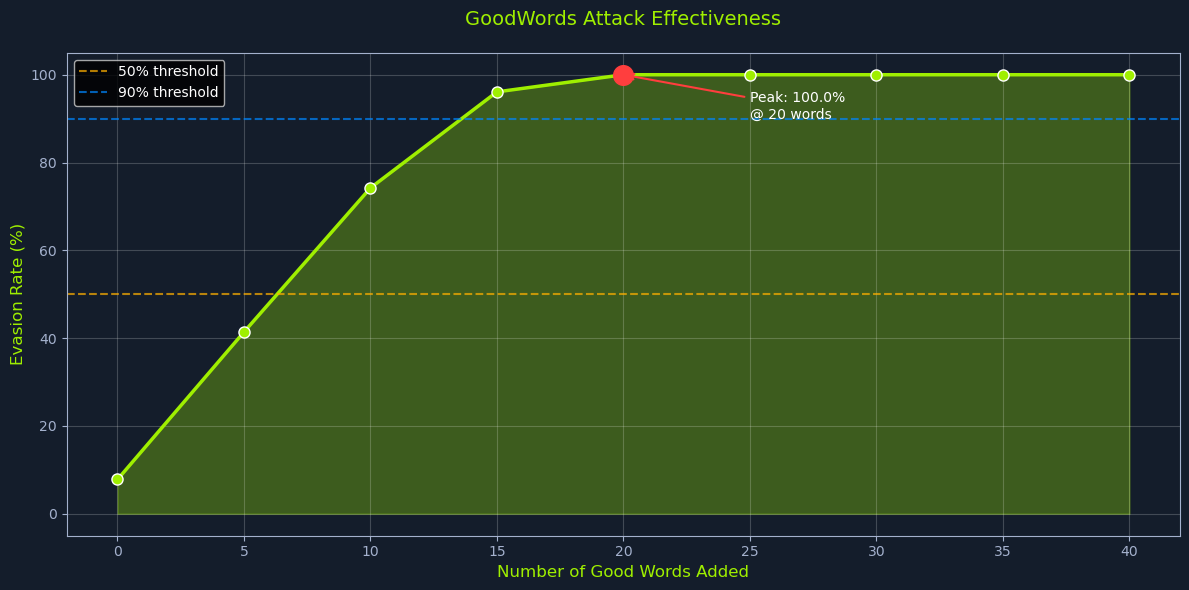


[+] Plot saved to attachments/attack_effectiveness.png


In [30]:
# attack effectiveness visualization
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 6), facecolor=NODE_BLACK)

ax.plot(results_df['num_words'], results_df['evasion_rate'],
        marker='o', markersize=8, linewidth=2.5,
        color=HTB_GREEN, markeredgecolor='white', markeredgewidth=1)

ax.fill_between(results_df['num_words'], 0, results_df['evasion_rate'],
                alpha=0.3, color=HTB_GREEN)
# Add threshold lines
ax.axhline(y=50, color=NUGGET_YELLOW, linestyle='--', alpha=0.7, label='50% threshold')
ax.axhline(y=90, color=AZURE, linestyle='--', alpha=0.7, label='90% threshold')

# Highlight maximum
max_idx = results_df['evasion_rate'].idxmax()
max_rate = results_df.loc[max_idx, 'evasion_rate']
max_words = results_df.loc[max_idx, 'num_words']
ax.scatter(max_words, max_rate, s=200, color=MALWARE_RED, zorder=5)
ax.annotate(f'Peak: {max_rate:.1f}%\n@ {max_words} words',
           xy=(max_words, max_rate), xytext=(max_words+5, max_rate-10),
           color='white', fontsize=10,
           arrowprops=dict(arrowstyle='->', color=MALWARE_RED, lw=1.5))

ax.set_xlabel('Number of Good Words Added', fontsize=12, color=HTB_GREEN)
ax.set_ylabel('Evasion Rate (%)', fontsize=12, color=HTB_GREEN)
ax.set_title('GoodWords Attack Effectiveness', fontsize=14, color=HTB_GREEN, pad=20)
ax.grid(True, alpha=0.2)
ax.set_facecolor(NODE_BLACK)
ax.legend()

for spine in ax.spines.values():
    spine.set_color(HACKER_GREY)
ax.tick_params(colors=HACKER_GREY)

plt.tight_layout()
output_dir = Path("attachments")
output_dir.mkdir(exist_ok=True)
plt.savefig(output_dir / "attack_effectiveness.png", dpi=150, facecolor=NODE_BLACK)
plt.show()
plt.close()
print(f"\n[+] Plot saved to {output_dir / 'attack_effectiveness.png'}")


## Attack Analysis and Visualization

In [36]:
# testing the impact of words added individually

# add each word individually to spam messages, measure its probability shift, and average across all messages
print("\n[*] Analyzing individual word impact...")

# use 50 spam messages as a representative sample
sample_spam = spam_test_messages[:50]
word_impacts = []

print(f"[+] Testing {len(top_good_words[:20])} words on {len(sample_spam)} spam messages")

for word, _, _, _ in top_good_words[:20]:
    total_impact = 0
    for message in sample_spam:
        # calculate original spam probability
        vec_orig = vectorizer.transform([message])
        prob_orig = classifier.predict_proba(vec_orig)[0][1] # spam prob

        # calculate probability after adding the word
        vec_aug = vectorizer.transform([message + " " + word])
        prob_aug = classifier.predict_proba(vec_aug)[0][1]

        # measure the probability reduction
        impact = prob_orig - prob_aug
        total_impact += impact

    # calculate average impact across all message
    avg_impact = (total_impact / len(sample_spam))*100
    word_impacts.append((word, avg_impact))

    # Show progress for first few words
    if len(word_impacts) <= 3:
        print(f"  Word '{word}': {avg_impact:.2f}% reduction")
# Ranking words by effectiveness
word_impacts.sort(key=lambda x: x[1], reverse=True)


[*] Analyzing individual word impact...
[+] Testing 20 words on 50 spam messages
  Word 'lor': 6.54% reduction
  Word 'ü': 6.44% reduction
  Word '...': 6.38% reduction


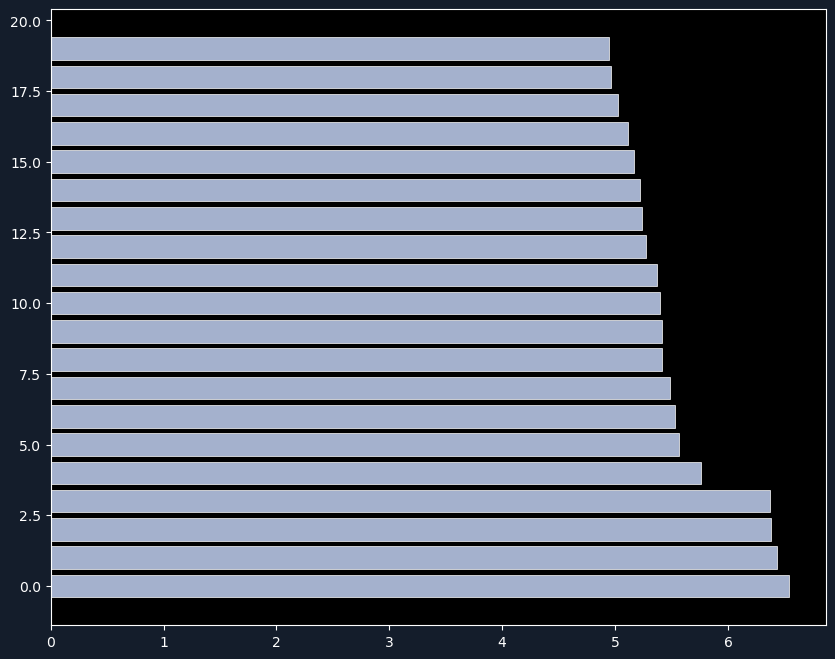

In [ ]:
# create an horizontal bar chart to see how individual words contribute to attack success
# Plot word impacts
fig, ax = plt.subplots(figsize=(10, 8), facecolor=NODE_BLACK)

words = [w for w, _ in word_impacts]
impacts = [i for _, i in word_impacts]
colors = [HTB_GREEN if i > 15 else NUGGET_YELLOW if i > 10 else HACKER_GREY for i in impacts]

bars = ax.barh(range(len(words)), impacts, color=colors, edgecolor='white', linewidth=0.5)


In [38]:
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.set_xlabel('Average Spam Probability Reduction (%)', fontsize=12, color=HTB_GREEN)
ax.set_title('Individual Word Impact on Spam Detection', fontsize=14, color=HTB_GREEN, pad=20)
ax.grid(axis='x', alpha=0.2)
ax.set_facecolor(NODE_BLACK)

for spine in ax.spines.values():
    spine.set_color(HACKER_GREY)
ax.tick_params(colors=HACKER_GREY)

plt.tight_layout()
plt.savefig(output_dir / "word_impact.png", dpi=150, facecolor=NODE_BLACK)
plt.close()
print(f"[+] Plot saved to {output_dir / 'word_impact.png'}")

[+] Plot saved to attachments/word_impact.png



[*] Visualizing probability shifts...


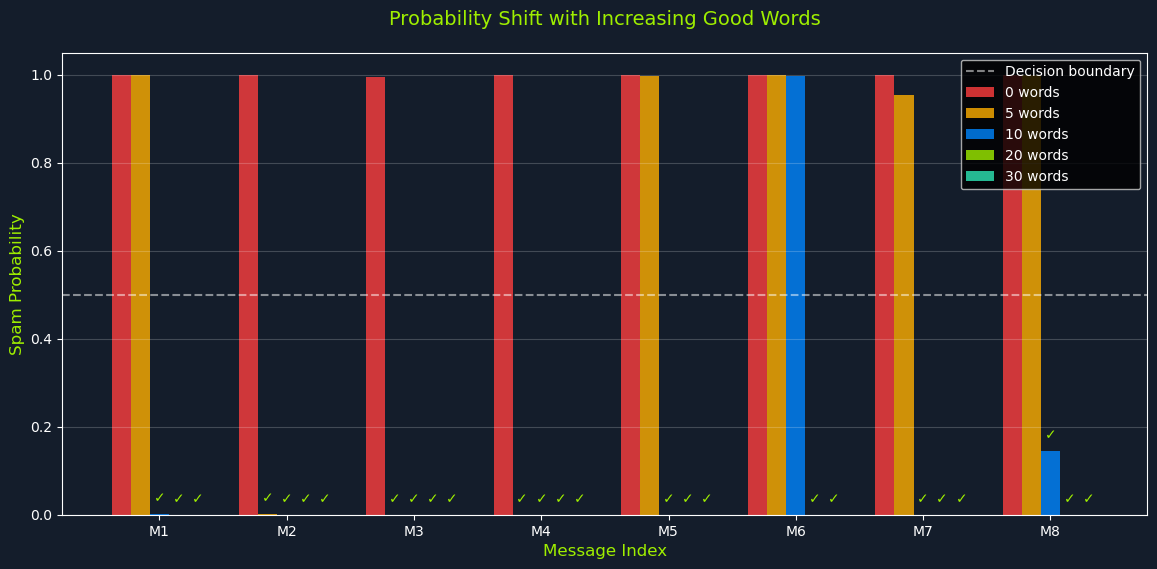

In [41]:
# probability shift analysis

# test spam messages with increasing augmentation levels
print("\n[*] Visualizing probability shifts...")

# Sample messages for detailed analysis
sample_messages = spam_test_messages[:8]
test_word_counts = [0, 5, 10, 20, 30]

fig, ax = plt.subplots(figsize=(14, 6), facecolor=NODE_BLACK)

x = np.arange(len(sample_messages))
width = 0.15
colors_list = [MALWARE_RED, NUGGET_YELLOW, AZURE, HTB_GREEN, AQUAMARINE]

for i, num_words in enumerate(test_word_counts):
    # Select the appropriate number of good words
    selected = [w for w, _, _, _ in top_good_words[:num_words]]
    probs = []
    for msg in sample_messages:
        # Augment message with selected words
        if num_words > 0:
            aug_msg = msg + " " + " ".join(selected)
        else:
            aug_msg = msg

        # Calculate spam probability
        vec = vectorizer.transform([aug_msg])
        spam_prob = classifier.predict_proba(vec)[0][1]
        probs.append(spam_prob)
    
    # Create grouped bars with distinct colors
    bars = ax.bar(x + i*width, probs, width,
                   label=f'{num_words} words',
                   color=colors_list[i], alpha=0.8)
    
    # Mark successful evasions
    for j, (bar, prob) in enumerate(zip(bars, probs)):
        if prob < 0.5:
            ax.text(bar.get_x() + bar.get_width()/2, prob + 0.02,
                   '✓', ha='center', va='bottom', color=HTB_GREEN, fontweight='bold')

# add the decision boundary
ax.axhline(y=0.5, color='white', linestyle='--', alpha=0.5, label='Decision boundary')
ax.set_xlabel('Message Index', fontsize=12, color=HTB_GREEN)
ax.set_ylabel('Spam Probability', fontsize=12, color=HTB_GREEN)
ax.set_title('Probability Shift with Increasing Good Words', fontsize=14, color=HTB_GREEN, pad=20)
ax.set_xticks(x + width * 2)
ax.set_xticklabels([f'M{i+1}' for i in range(len(sample_messages))])
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.2)
ax.set_facecolor(NODE_BLACK)


In [42]:
# save the visualization
for spine in ax.spines.values():
    spine.set_color(HACKER_GREY)
ax.tick_params(colors=HACKER_GREY)

plt.tight_layout()
plt.savefig(output_dir / "probability_shift.png", dpi=150, facecolor=NODE_BLACK)
plt.close()
print(f"[+] Plot saved to {output_dir / 'probability_shift.png'}")

[+] Plot saved to attachments/probability_shift.png
